In [1]:
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt
from sklearn.decomposition import NMF

import config
from data import load_utk
from utils import apply_symmetric_noise

In [2]:
MAX_ITER = 100000

In [3]:
array = load_utk()
noisy_array = apply_symmetric_noise(array, prob=0.15)
binarized_array = (array / array.max(axis=1, keepdims=True) > 0.5).astype(array.dtype)

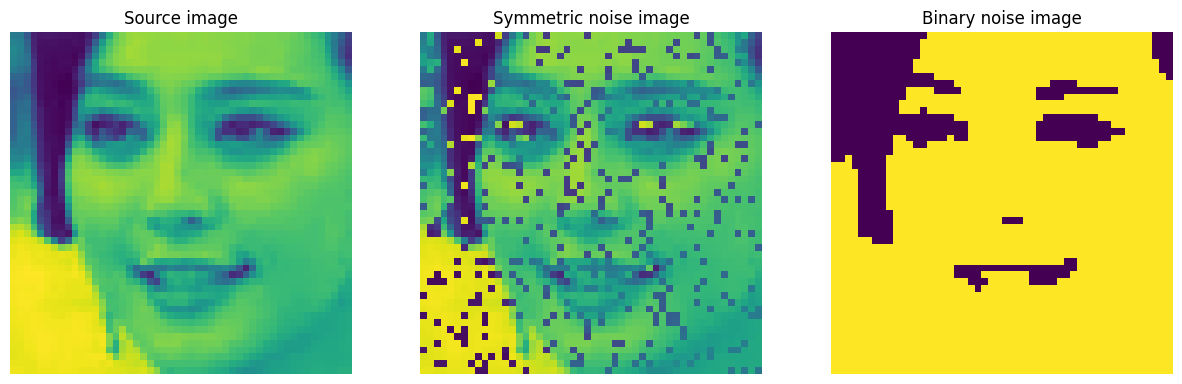

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

idx = 50

axes[0].imshow(array[idx].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[0].set_title("Source image")
axes[0].axis("off")

axes[1].imshow(noisy_array[idx].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[1].set_title("Symmetric noise image")
axes[1].axis("off")

axes[2].imshow(binarized_array[idx].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[2].set_title("Binary noise image")
axes[2].axis("off")

# plt.savefig("NNMF look at original and denoised.pdf")
plt.show()

### Binary case

In [5]:
seed = 42

In [6]:
# rank_108 = 108

# model_108 = NMF(n_components=rank_108, max_iter=MAX_ITER, init="random", random_state=seed)
# W_sklearn_108 = model_108.fit_transform(binarized_array)
# H_sklearn_108 = model_108.components_
# H_sklearn_reshaped_108 = H_sklearn_108.reshape(rank_108, config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])

In [7]:
# rank_72 = 72

# model_72 = NMF(n_components=rank_72, max_iter=MAX_ITER, init="random", random_state=seed)
# W_sklearn_72 = model_72.fit_transform(binarized_array)
# H_sklearn_72 = model_72.components_
# H_sklearn_reshaped_72 = H_sklearn_72.reshape(rank_72, config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])

In [8]:
rank_36 = 36

model_36 = NMF(n_components=rank_36, max_iter=MAX_ITER, init="random", random_state=seed)
W_sklearn_36 = model_36.fit_transform(binarized_array)
H_sklearn_36 = model_36.components_
H_sklearn_reshaped_36 = H_sklearn_36.reshape(rank_36, config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])

In [9]:
# recovered_array_108 = np.dot(W_sklearn_108, H_sklearn_108)
# recovered_array_72 = np.dot(W_sklearn_72, H_sklearn_72)
recovered_array_36 = np.dot(W_sklearn_36, H_sklearn_36)

In [10]:
def get_sorted_indices(vector, dataset_arr):
    vector_flat = vector.flatten()
    dataset_flat = dataset_arr.reshape(dataset_arr.shape[0], -1)
    
    dot_products = np.dot(dataset_flat, vector_flat)
    
    norm_vector = np.linalg.norm(vector_flat)
    norms_dataset = np.linalg.norm(dataset_flat, axis=1)
    
    epsilon = 1e-10
    norms_dataset = np.where(norms_dataset == 0, epsilon, norms_dataset)
    norm_vector = norm_vector if norm_vector != 0 else epsilon
    
    cosine_similarities = dot_products / (norm_vector * norms_dataset)
    
    return np.argsort(-cosine_similarities)

In [11]:
# place_list_108 = list()
# # for idx in tqdm(range(recovered_array_binarized.shape[0])):
# for idx in tqdm(range(1000)):
#     sorted_indices = get_sorted_indices(recovered_array_108[idx], array)
#     found_indices = np.argwhere(sorted_indices == idx).flatten()
#     assert len(found_indices) == 1
#     place_list_108.append(found_indices.item())

# k_list_108 = list(range(1, 500))
# accuracy_at_k_list_108 = list()
# for k in tqdm(k_list_108):
#     accuracy_at_k = len([num for num in place_list_108 if num < k]) / len(place_list_108)
#     accuracy_at_k_list_108.append(accuracy_at_k)

In [12]:
# place_list_72 = list()
# # for idx in tqdm(range(recovered_array_binarized.shape[0])):
# for idx in tqdm(range(1000)):
#     sorted_indices = get_sorted_indices(recovered_array_72[idx], array)
#     found_indices = np.argwhere(sorted_indices == idx).flatten()
#     assert len(found_indices) == 1
#     place_list_72.append(found_indices.item())

# k_list_72 = list(range(1, 500))
# accuracy_at_k_list_72 = list()
# for k in tqdm(k_list_72):
#     accuracy_at_k = len([num for num in place_list_72 if num < k]) / len(place_list_72)
#     accuracy_at_k_list_72.append(accuracy_at_k)

In [13]:
place_list_36 = list()
# for idx in tqdm(range(recovered_array_binarized.shape[0])):
for idx in tqdm(range(1000)):
    sorted_indices = get_sorted_indices(recovered_array_36[idx], array)
    found_indices = np.argwhere(sorted_indices == idx).flatten()
    assert len(found_indices) == 1
    place_list_36.append(found_indices.item())

k_list_36 = list(range(1, 500))
accuracy_at_k_list_36 = list()
for k in tqdm(k_list_36):
    accuracy_at_k = len([num for num in place_list_36 if num < k]) / len(place_list_36)
    accuracy_at_k_list_36.append(accuracy_at_k)



00%|██████████████████████████████████████| 499/499 [00:00<00:00, 62057.69it/s]

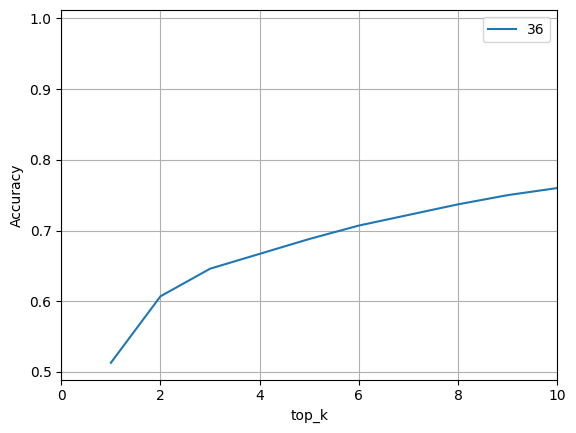

In [14]:
# plt.plot(k_list_108, accuracy_at_k_list_108, label="108")
# plt.plot(k_list_72, accuracy_at_k_list_72, label="72")
plt.plot(k_list_36, accuracy_at_k_list_36, label="36")

plt.xlabel("top_k")
plt.ylabel("Accuracy")

plt.grid()

plt.legend()

plt.xlim(0, 10)

plt.show()

False


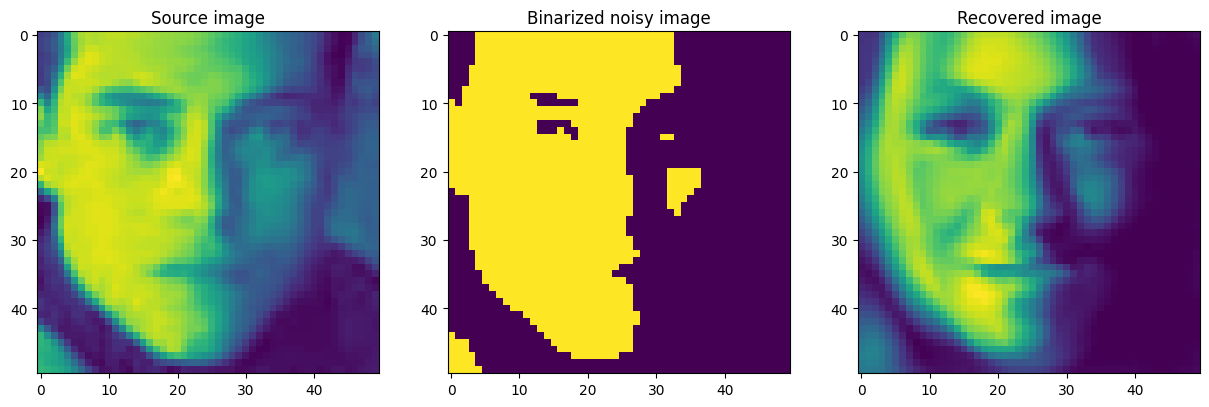

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

idx = 6
sorted_indices = get_sorted_indices(recovered_array_36[idx], array)

print(sorted_indices[0] == 50)

axes[0].imshow(array[sorted_indices[0]].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[0].set_title("Source image")

axes[1].imshow(binarized_array[idx].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[1].set_title("Binarized noisy image")

axes[2].imshow(recovered_array_36[idx].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[2].set_title("Recovered image")

plt.savefig("NNMF look at original and denoised.pdf")
plt.show()

In [23]:
1

1

In [ ]:
plt.plot(df_data.k_hidden, df_data.nnmf_arr, label="NNMF ARR")
plt.plot(df_data.k_hidden, df_data.pca_arr, label="PCA ARR")
plt.plot(df_data.k_hidden, df_data.dict_arr, label="Dict ARR")
# plt.axvline(16, color="black")

plt.xlabel("k_hidden")
plt.ylabel("ARR")

plt.grid()

plt.legend()

plt.savefig("Swimmer_compare_arr.pdf")

plt.show()

In [5]:
rank = 100

seed = config.SEED
model_binarized = NMF(n_components=rank, max_iter=MAX_ITER, init="random", random_state=seed)
W_sklearn_binarized = model_binarized.fit_transform(binarized_array)
H_sklearn_binarized = model_binarized.components_

In [6]:
recovered_array_binarized = np.dot(W_sklearn_binarized, H_sklearn_binarized)

In [7]:
def get_sorted_indices(vector, dataset_arr):
    vector_flat = vector.flatten()
    dataset_flat = dataset_arr.reshape(dataset_arr.shape[0], -1)
    
    dot_products = np.dot(dataset_flat, vector_flat)
    
    norm_vector = np.linalg.norm(vector_flat)
    norms_dataset = np.linalg.norm(dataset_flat, axis=1)
    
    epsilon = 1e-10
    norms_dataset = np.where(norms_dataset == 0, epsilon, norms_dataset)
    norm_vector = norm_vector if norm_vector != 0 else epsilon
    
    cosine_similarities = dot_products / (norm_vector * norms_dataset)
    
    return np.argsort(-cosine_similarities)

False


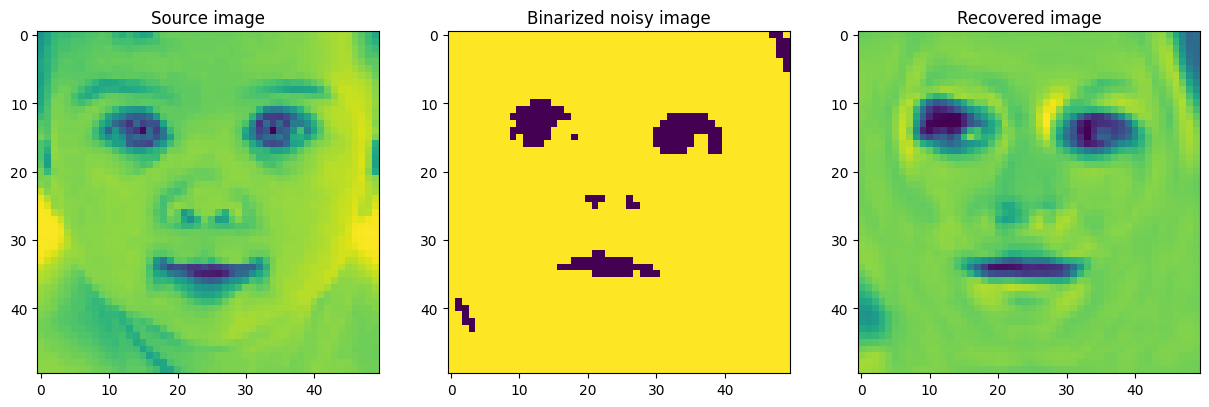

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

idx = 3
sorted_indices = get_sorted_indices(recovered_array_binarized[idx], array)

print(sorted_indices[0] == 50)

axes[0].imshow(array[sorted_indices[0]].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[0].set_title("Source image")

axes[1].imshow(binarized_array[idx].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[1].set_title("Binarized noisy image")

axes[2].imshow(recovered_array_binarized[idx].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[2].set_title("Recovered image")

plt.savefig("NNMF look at original and denoised.pdf")
plt.show()

In [9]:
place_list = list()
# for idx in tqdm(range(recovered_array_binarized.shape[0])):
for idx in tqdm(range(1000)):
    sorted_indices = get_sorted_indices(recovered_array_binarized[idx], array)
    found_indices = np.argwhere(sorted_indices == idx).flatten()
    assert len(found_indices) == 1
    place_list.append(found_indices.item())


00%|███████████████████████████████████████| 1000/1000 [01:44<00:00,  9.59it/s]

In [10]:
k_list = list(range(1, 500))

accuracy_at_k_list = list()
for k in tqdm(k_list):
    accuracy_at_k = len([num for num in place_list if num < k]) / len(place_list)
    accuracy_at_k_list.append(accuracy_at_k)


00%|██████████████████████████████████████| 499/499 [00:00<00:00, 32783.91it/s]

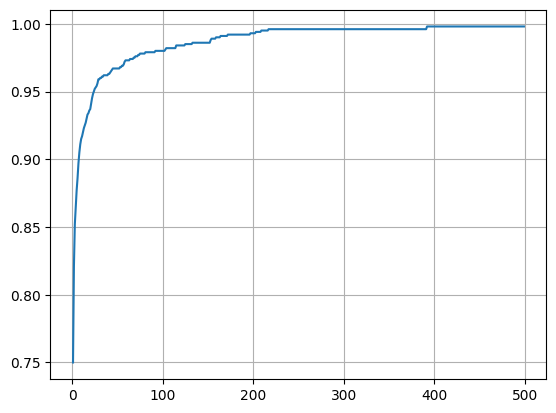

In [11]:
plt.plot(k_list, accuracy_at_k_list)
plt.grid()
plt.show()

In [12]:
accuracy_at_k_list

[0.75,
 0.821,
 0.852,
 0.865,
 0.877,
 0.886,
 0.897,
 0.905,
 0.911,
 0.915,
 0.917,
 0.92,
 0.923,
 0.925,
 0.927,
 0.93,
 0.933,
 0.934,
 0.936,
 0.937,
 0.941,
 0.945,
 0.948,
 0.95,
 0.952,
 0.953,
 0.954,
 0.956,
 0.959,
 0.959,
 0.96,
 0.96,
 0.961,
 0.961,
 0.962,
 0.962,
 0.962,
 0.962,
 0.962,
 0.963,
 0.963,
 0.964,
 0.965,
 0.966,
 0.967,
 0.967,
 0.967,
 0.967,
 0.967,
 0.967,
 0.967,
 0.967,
 0.968,
 0.968,
 0.969,
 0.969,
 0.97,
 0.972,
 0.973,
 0.973,
 0.973,
 0.973,
 0.973,
 0.974,
 0.974,
 0.974,
 0.974,
 0.975,
 0.975,
 0.976,
 0.976,
 0.976,
 0.977,
 0.977,
 0.978,
 0.978,
 0.978,
 0.978,
 0.978,
 0.978,
 0.979,
 0.979,
 0.979,
 0.979,
 0.979,
 0.979,
 0.979,
 0.979,
 0.979,
 0.979,
 0.979,
 0.98,
 0.98,
 0.98,
 0.98,
 0.98,
 0.98,
 0.98,
 0.98,
 0.98,
 0.98,
 0.98,
 0.981,
 0.982,
 0.982,
 0.982,
 0.982,
 0.982,
 0.982,
 0.982,
 0.982,
 0.982,
 0.982,
 0.982,
 0.984,
 0.984,
 0.984,
 0.984,
 0.984,
 0.984,
 0.984,
 0.984,
 0.984,
 0.984,
 0.985,
 0.985,
 0.985,
 0

### Binary noise case

In [13]:
rank = 100

seed = config.SEED
model_noisy = NMF(n_components=rank, max_iter=MAX_ITER, init="random", random_state=seed)
W_sklearn_noisy = model_noisy.fit_transform(noisy_array)
H_sklearn_noisy = model_noisy.components_

In [ ]:
recovered_array_noisy = np.dot(W_sklearn_noisy, H_sklearn_noisy)

False


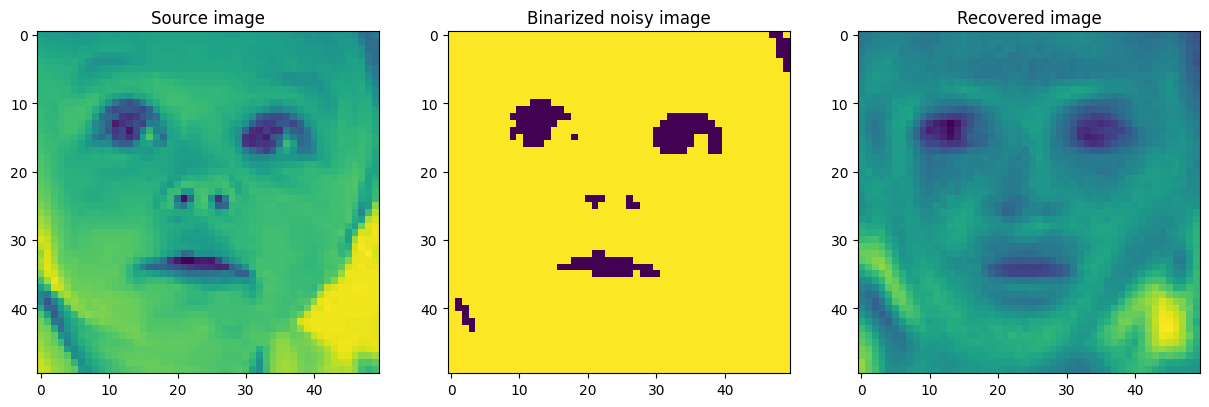

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

idx = 3
sorted_indices = get_sorted_indices(recovered_array_noisy[idx], array)

print(sorted_indices[0] == 50)

axes[0].imshow(array[sorted_indices[0]].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[0].set_title("Source image")

axes[1].imshow(binarized_array[idx].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[1].set_title("Binarized noisy image")

axes[2].imshow(recovered_array_noisy[idx].reshape((config.IMAGE_SIZE["UTK"], config.IMAGE_SIZE["UTK"])), cmap="viridis")
axes[2].set_title("Recovered image")

plt.savefig("NNMF look at original and denoised.pdf")
plt.show()

In [ ]:
place_list = list()
# for idx in tqdm(range(recovered_array_binarized.shape[0])):
for idx in tqdm(range(1000)):
    sorted_indices = get_sorted_indices(recovered_array_noisy[idx], array)
    found_indices = np.argwhere(sorted_indices == idx).flatten()
    assert len(found_indices) == 1
    place_list.append(found_indices.item())


00%|███████████████████████████████████████| 1000/1000 [01:28<00:00, 11.25it/s]

In [ ]:
k_list = list(range(1, 500))

accuracy_at_k_list = list()
for k in tqdm(k_list):
    accuracy_at_k = len([num for num in place_list if num < k]) / len(place_list)
    accuracy_at_k_list.append(accuracy_at_k)


00%|██████████████████████████████████████| 499/499 [00:00<00:00, 56182.26it/s]

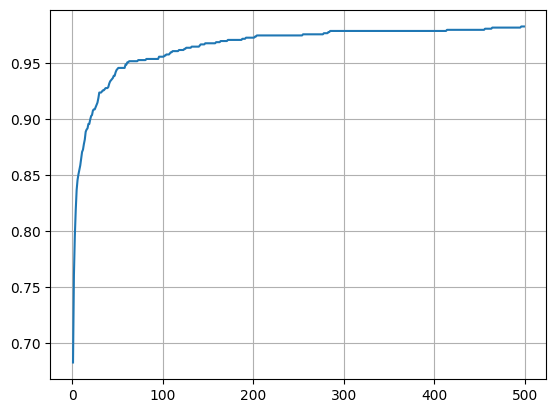

In [ ]:
plt.plot(k_list, accuracy_at_k_list)
plt.grid()
plt.show()

In [28]:
440 * 3 + 1665 / 3 + 2265 / 3 + 2975 / 5 + 950

4175.0